In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# Load the data from the CSV file
df = pd.read_csv(
    "LUMEN_DS.csv",
    sep="|",
    quotechar='"',
    encoding="utf-16",
    low_memory=False,
)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1294962 entries, 0 to 1294961
Data columns (total 33 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   Manufacturing Region                 1254453 non-null  str    
 1   Manufacturing Location Code          1255003 non-null  str    
 2   Intercompany                         1294962 non-null  str    
 3   CustomerID                           1294962 non-null  int64  
 4   Customer industry                    1294962 non-null  str    
 5   Customer Region                      1294859 non-null  str    
 6   Customer First Invoice Date          1294962 non-null  str    
 7   Top Customer Group                   1294962 non-null  str    
 8   Item Code                            1294907 non-null  str    
 9   Product family                       1294962 non-null  str    
 10  Product group                        1126302 non-null  str    
 11  Price las

Using columns -> customer: CustomerID , group: Product group , quantity (detected): Invoiced qty (shipped)
Found 9946 customers with more than 10 total purchased products.


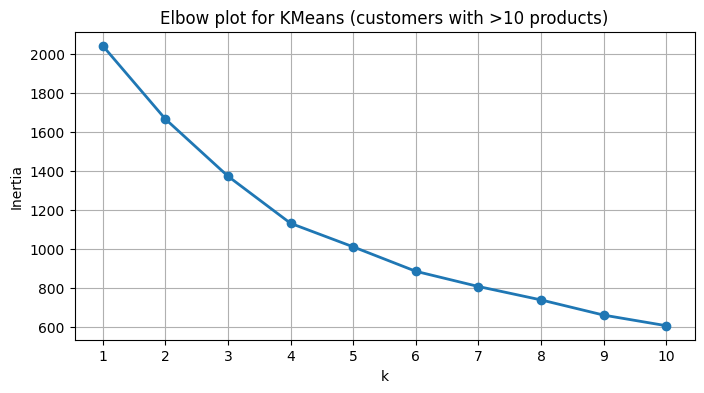

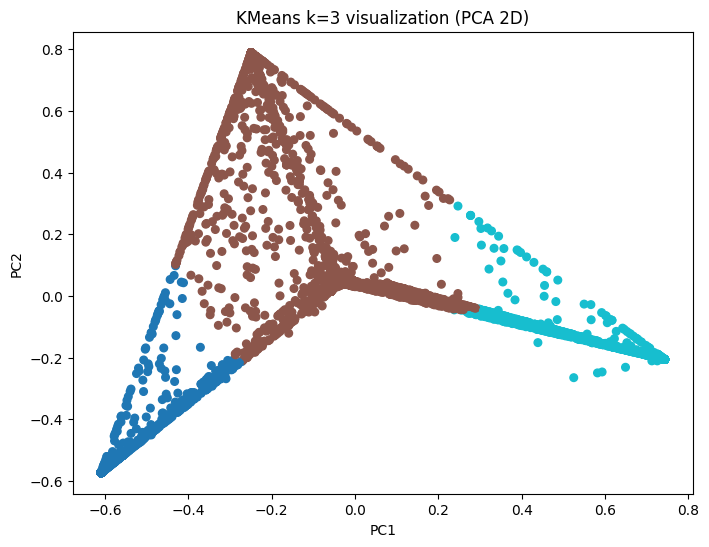

Percent vector shape (customers x product_groups): (9946, 33)


Product group,2016-11-02 00:00:00,2018-09-01 00:00:00,PC001,PC002,PC003,PC004,PC005,PC006,PC007,PC008,...,PC022,PC023,PC024,PC025,PC026,PC028,PC029,PC030,SF001,SF002
CustomerID,,,,,,,,,,,,,,,,,,,,,
-99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.098214,...,0.0,0.0,0.0,0.0,0.901554,0.0,0.0,0.0,0.0,0.0
13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [3]:
# Build customer vectors (only customers with > 10 total products)
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Use explicit columns provided by the user
cols = list(df.columns)
cust_col = 'CustomerID'
group_col = 'Product group'
# try to detect a quantity column, otherwise assume each row = 1
qty_col = next((c for c in cols if 'qty' in c.lower() or 'quantity' in c.lower() or 'count' in c.lower() or 'units' in c.lower()), None)

print('Using columns -> customer:', cust_col, ', group:', group_col, ', quantity (detected):', qty_col)

# Validate required columns exist
if cust_col not in df.columns:
    raise ValueError(f'Column "{cust_col}" not found in dataframe. Available columns: {cols}')
if group_col not in df.columns:
    raise ValueError(f'Column "{group_col}" not found in dataframe. Available columns: {cols}')

# If no quantity column, assume each row represents a single product (qty = 1)
working_df = df.copy()
if qty_col is None:
    working_df['_qty'] = 1
    qty_col = '_qty'

# Aggregate counts per customer x group
agg = working_df.groupby([cust_col, group_col])[qty_col].sum().reset_index()
# total per customer
totals = agg.groupby(cust_col)[qty_col].sum().reset_index().rename(columns={qty_col: 'total_qty'})
# filter customers with > 10 products
customers_over10 = totals.loc[totals['total_qty'] > 10, cust_col].unique()
print(f'Found {len(customers_over10)} customers with more than 10 total purchased products.')

agg_filtered = agg[agg[cust_col].isin(customers_over10)]
# pivot to get one vector per customer (counts per group)
pivot = agg_filtered.pivot_table(index=cust_col, columns=group_col, values=qty_col, fill_value=0)
# convert counts into percentages of that customer's total purchases
percent = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)
percent = percent.astype(float).round(12)

# Create unique-vector groups to guarantee identical vectors -> identical cluster + PCA point
row_keys = pd.util.hash_pandas_object(percent, index=False)
unique_percent = percent.groupby(row_keys, sort=False).first()

# Elbow plot on unique vectors (avoids overweighting duplicate rows)
inertias = []
Ks = range(1, 11)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(unique_percent)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(Ks), inertias, 'o-', linewidth=2)
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow plot for KMeans (customers with >10 products)')
plt.xticks(list(Ks))
plt.grid(True)
plt.show()

# Main section: k = 3
k_vis = 3  # keep the original notebook flow at 3 clusters
if len(unique_percent) >= k_vis:
    km_vis = KMeans(n_clusters=k_vis, random_state=42, n_init=10)
    unique_labels = km_vis.fit_predict(unique_percent)

    # Map labels back to all customers: identical vectors share the same key -> same label
    key_to_label = pd.Series(unique_labels, index=unique_percent.index)
    labels = row_keys.map(key_to_label).to_numpy(dtype=int)

    # PCA on unique vectors, then map coordinates back so duplicates are exactly overlapping
    pca = PCA(n_components=2, random_state=42)
    unique_coords = pca.fit_transform(unique_percent)
    key_to_coords = pd.DataFrame(unique_coords, index=unique_percent.index, columns=['PC1', 'PC2'])
    coords = key_to_coords.loc[row_keys].to_numpy()

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab10', s=30)
    plt.title(f'KMeans k={k_vis} visualization (PCA 2D)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(False)
    plt.show()
else:
    print('Not enough unique customer vectors to visualize for k=', k_vis)

# Show the shape of the percent vectors (customers x product_groups) and first rows
print('Percent vector shape (customers x product_groups):', percent.shape)
display(percent.head())

In [4]:
# Display centroids and cluster sizes for chosen k

# Check if labels and percent variables exist from the previous cell
if 'labels' in locals() and 'percent' in locals():
    # Count number of elements in each cluster
    cluster_counts = pd.Series(labels).value_counts().sort_index()

    print("Number of customers in each cluster:")
    for cluster_id, count in cluster_counts.items():
        print(f"Cluster {cluster_id}: {count} customers")

    # Compute centroids from corrected labels (guarantees consistency)
    centroid_df = percent.copy()
    centroid_df['cluster'] = labels
    centroid_df = centroid_df.groupby('cluster').mean().sort_index()

    print("\nCluster Centroids (Top 5 product groups for each cluster):")
    for cluster_id in centroid_df.index:
        print(f"\n----- Centroid for Cluster {cluster_id} -----")
        # Sort the product groups for the current centroid by percentage, in descending order
        top_groups = centroid_df.loc[cluster_id].sort_values(ascending=False)
        # Display the top 5
        print(top_groups.head(5))
else:
    print("Please run the previous cell first to perform clustering and define labels.")


Number of customers in each cluster:
Cluster 0: 1970 customers
Cluster 1: 5264 customers
Cluster 2: 2712 customers

Cluster Centroids (Top 5 product groups for each cluster):

----- Centroid for Cluster 0 -----
Product group
PC013    0.951630
PC026    0.010003
PC025    0.009691
PC014    0.009009
SF002    0.006142
Name: 0, dtype: float64

----- Centroid for Cluster 1 -----
Product group
PC026    0.276619
PC022    0.094101
PC001    0.087904
PC021    0.056150
PC025    0.056047
Name: 1, dtype: float64

----- Centroid for Cluster 2 -----
Product group
PC010    0.930226
PC001    0.028385
PC021    0.009104
PC016    0.005837
PC011    0.005574
Name: 2, dtype: float64


In [5]:
# Perform PCA and display the top 3 components

if 'percent' in locals():
    # Initialize PCA with 3 components
    pca_3 = PCA(n_components=3, random_state=42)
    
    # Fit PCA on the percentage vectors
    pca_3.fit(percent)
    
    # Create a DataFrame for the principal components
    components_df = pd.DataFrame(pca_3.components_, columns=percent.columns)
    
    print("Explained Variance Ratio by each component:")
    for i, variance in enumerate(pca_3.explained_variance_ratio_):
        print(f"  Component {i+1}: {variance:.4f} ({variance:.2%})")
        
    print(f"\nTotal variance explained by 3 components: {sum(pca_3.explained_variance_ratio_):.4f} ({sum(pca_3.explained_variance_ratio_):.2%})")

    print("\nTop 10 influential product groups for each Principal Component:")
    for i in range(len(components_df)):
        print(f"\n----- Principal Component {i+1} -----")
        # Sort by absolute value to see the most influential groups, regardless of direction
        top_groups = components_df.iloc[i].reindex(components_df.iloc[i].abs().sort_values(ascending=False).index)
        print(top_groups.head(10))
else:
    print("Please run the cell that defines the 'percent' DataFrame first.")


Explained Variance Ratio by each component:
  Component 1: 0.2832 (28.32%)
  Component 2: 0.1980 (19.80%)
  Component 3: 0.1119 (11.19%)

Total variance explained by 3 components: 0.5931 (59.31%)

Top 10 influential product groups for each Principal Component:

----- Principal Component 1 -----
Product group
PC010    0.831329
PC013   -0.528474
PC026   -0.166685
PC022   -0.024041
PC025   -0.020317
PC014   -0.013830
PC019   -0.013432
PC012   -0.010584
PC002   -0.009317
PC009   -0.008275
Name: 0, dtype: float64

----- Principal Component 2 -----
Product group
PC026    0.688857
PC013   -0.663920
PC010   -0.280758
PC022    0.044769
PC001    0.037046
PC025    0.021987
PC021    0.020588
PC019    0.018485
PC009    0.018342
PC012    0.016784
Name: 1, dtype: float64

----- Principal Component 3 -----
Product group
PC026    0.642571
PC013    0.445507
PC010    0.393546
PC022   -0.310767
PC001   -0.264964
PC021   -0.129187
PC009   -0.102531
PC025   -0.086201
PC019   -0.086085
PC012   -0.077358
Name

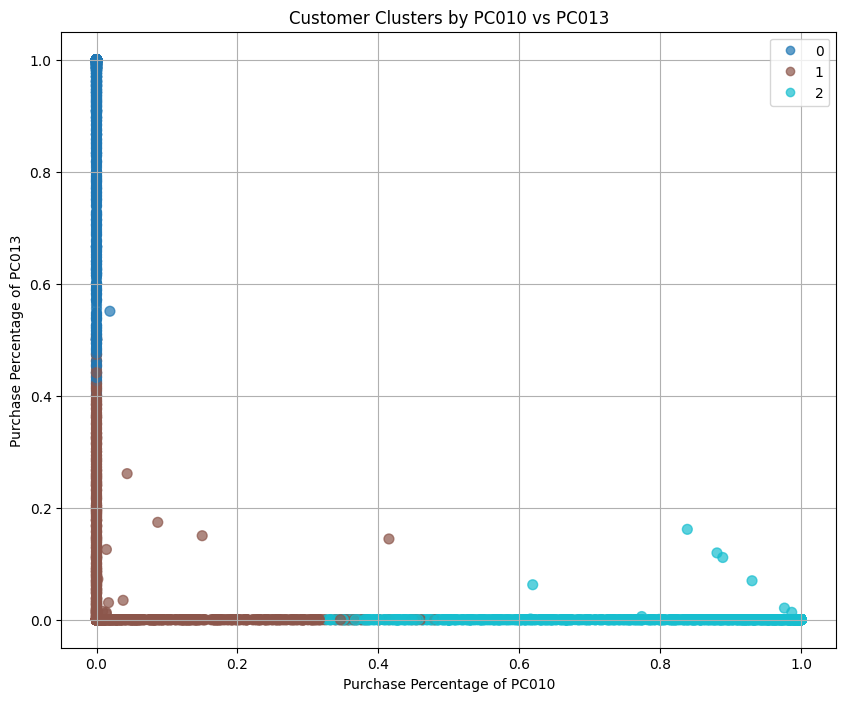

In [6]:
# Plot clusters using PC010 and PC013 as coordinates

# Check if the necessary variables from previous cells exist
if 'percent' in locals() and 'labels' in locals():
    
    # Define the columns to use for the plot
    x_axis_col = 'PC010'
    y_axis_col = 'PC013'
    
    # Check if the specified columns exist in the DataFrame
    if x_axis_col in percent.columns and y_axis_col in percent.columns:
        plt.figure(figsize=(10, 8))
        
        # Create a scatter plot
        scatter = plt.scatter(
            percent[x_axis_col], 
            percent[y_axis_col], 
            c=labels, 
            cmap='tab10', 
            s=50,
            alpha=0.7
        )
        
        plt.title(f'Customer Clusters by {x_axis_col} vs {y_axis_col}')
        plt.xlabel(f'Purchase Percentage of {x_axis_col}')
        plt.ylabel(f'Purchase Percentage of {y_axis_col}')
        
        # Create a legend for the clusters
        plt.legend(handles=scatter.legend_elements()[0], labels=range(k_vis))
        
        plt.grid(True)
        plt.show()
    else:
        print(f"Error: One or both columns '{x_axis_col}', '{y_axis_col}' not found in the data.")
        print(f"Available columns are: {percent.columns.tolist()}")

else:
    print("Please make sure to run the previous cells to define the 'percent' DataFrame and 'labels' from clustering.")


In [7]:
import numpy as np
import pandas as pd
import plotly.express as px

# Correct interactive PCA plot: one point per unique original vector
if 'percent' in locals() and 'labels' in locals() and 'coords' in locals():
    base_df = pd.DataFrame({
        'CustomerID': percent.index.astype(str),
        'PC1': coords[:, 0],
        'PC2': coords[:, 1],
        'Cluster': labels.astype(int),
    })

    # Build a stable key from the original vector, so duplicates are grouped together.
    vector_key = pd.util.hash_pandas_object(percent, index=False).astype(str).to_numpy()
    base_df['vector_key'] = vector_key

    # Aggregate to one marker per unique vector.
    agg_df = (
        base_df.groupby('vector_key', as_index=False)
        .agg(
            PC1=('PC1', 'first'),
            PC2=('PC2', 'first'),
            Cluster=('Cluster', lambda s: int(s.mode().iloc[0])),
            n_customers=('CustomerID', 'size'),
            customer_ids=('CustomerID', lambda s: ', '.join(s.iloc[:15]) + (' ...' if len(s) > 15 else '')),
        )
    )

    # Add top product-group shares for hover text (computed once per unique vector).
    unique_vectors = percent.groupby(pd.Series(vector_key, index=percent.index), sort=False).first()

    def top_groups_text(row, k=5):
        top = row[row > 0].sort_values(ascending=False).head(k)
        if len(top) == 0:
            return '(all zeros)'
        return '<br>'.join([f'{idx}: {val:.1%}' for idx, val in top.items()])

    top_groups_map = unique_vectors.apply(top_groups_text, axis=1)
    agg_df['Top_Products'] = agg_df['vector_key'].map(top_groups_map)
    agg_df['Cluster'] = agg_df['Cluster'].astype(str)

    # Improve visibility: compress size range using log scale and cap max marker size.
    log_n = np.log1p(agg_df['n_customers'].astype(float))
    denom = max(log_n.max() - log_n.min(), 1e-9)
    agg_df['size_for_plot'] = 6.0 + 8.0 * (log_n - log_n.min()) / denom

    # Draw larger bubbles first so smaller ones remain visible on top.
    agg_df = agg_df.sort_values('size_for_plot', ascending=False).reset_index(drop=True)

    fig = px.scatter(
        agg_df,
        x='PC1',
        y='PC2',
        color='Cluster',
        size='size_for_plot',
        size_max=14,
        title='Interactive Customer Segments (PCA) - Unique Vectors',
        labels={
            'PC1': 'Principal Component 1',
            'PC2': 'Principal Component 2',
            'n_customers': 'Customers at this point',
            'customer_ids': 'Customer IDs (sample)',
            'size_for_plot': 'Marker size',
        },
        custom_data=['n_customers', 'customer_ids', 'Top_Products'],
    )

    fig.update_traces(
        marker=dict(opacity=0.65, line=dict(width=0.4, color='white')),
        hovertemplate=(
            '<b>Cluster:</b> %{marker.color}<br>'
            '<b>PC1:</b> %{x:.6f}<br>'
            '<b>PC2:</b> %{y:.6f}<br>'
            '<b>Customers at this point:</b> %{customdata[0]}<br>'
            '<b>Customer IDs (sample):</b> %{customdata[1]}<br>'
            '<b>Top 5 Groups:</b><br>%{customdata[2]}'
            '<extra></extra>'
        )
    )

    fig.update_layout(
        legend_title_text='Cluster',
        xaxis=dict(gridcolor='lightgrey'),
        yaxis=dict(gridcolor='lightgrey'),
        plot_bgcolor='white'
    )

    fig.show()
else:
    print("Please ensure the previous cells have been run to define 'percent', 'labels', and 'coords'.")

## K=4 clustering
The cells below repeat the same workflow for four clusters while keeping the original `k=3` analysis above intact.

In [8]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px
import matplotlib.pyplot as plt

# K = 4 version of the same workflow, kept separate from the k=3 cells above.
if 'percent' in locals() and 'row_keys' in locals() and 'unique_percent' in locals():
    k_vis_4 = 4

    if len(unique_percent) < k_vis_4:
        raise ValueError('Not enough unique customer vectors for k=4.')

    km_vis_4 = KMeans(n_clusters=k_vis_4, random_state=42, n_init=10)
    unique_labels_4 = km_vis_4.fit_predict(unique_percent)

    key_to_label_4 = pd.Series(unique_labels_4, index=unique_percent.index)
    labels_4 = row_keys.map(key_to_label_4).to_numpy(dtype=int)

    pca_4 = PCA(n_components=2, random_state=42)
    unique_coords_4 = pca_4.fit_transform(unique_percent)
    key_to_coords_4 = pd.DataFrame(unique_coords_4, index=unique_percent.index, columns=['PC1', 'PC2'])
    coords_4 = key_to_coords_4.loc[row_keys].to_numpy()

    cluster_counts_4 = pd.Series(labels_4).value_counts().sort_index()
    print('Number of customers in each cluster for k=4:')
    for cluster_id, count in cluster_counts_4.items():
        print(f'Cluster {cluster_id}: {count} customers')

    centroid_df_4 = percent.copy()
    centroid_df_4['cluster'] = labels_4
    centroid_df_4 = centroid_df_4.groupby('cluster').mean().sort_index()

    print('\nCluster Centroids for k=4 (Top 5 product groups for each cluster):')
    for cluster_id in centroid_df_4.index:
        print(f'\n----- Centroid for Cluster {cluster_id} -----')
        print(centroid_df_4.loc[cluster_id].sort_values(ascending=False).head(5))

    base_df_4 = pd.DataFrame({
        'CustomerID': percent.index.astype(str),
        'PC1': coords_4[:, 0],
        'PC2': coords_4[:, 1],
        'Cluster': labels_4.astype(int),
    })

    vector_key_4 = pd.util.hash_pandas_object(percent, index=False).astype(str).to_numpy()
    base_df_4['vector_key'] = vector_key_4

    agg_df_4 = (
        base_df_4.groupby('vector_key', as_index=False)
        .agg(
            PC1=('PC1', 'first'),
            PC2=('PC2', 'first'),
            Cluster=('Cluster', lambda s: int(s.mode().iloc[0])),
            n_customers=('CustomerID', 'size'),
            customer_ids=('CustomerID', lambda s: ', '.join(s.iloc[:15]) + (' ...' if len(s) > 15 else '')),
        )
    )

    unique_vectors_4 = percent.groupby(pd.Series(vector_key_4, index=percent.index), sort=False).first()

    def top_groups_text_4(row, k=5):
        top = row[row > 0].sort_values(ascending=False).head(k)
        if len(top) == 0:
            return '(all zeros)'
        return '<br>'.join([f'{idx}: {val:.1%}' for idx, val in top.items()])

    top_groups_map_4 = unique_vectors_4.apply(top_groups_text_4, axis=1)
    agg_df_4['Top_Products'] = agg_df_4['vector_key'].map(top_groups_map_4)
    agg_df_4['Cluster'] = agg_df_4['Cluster'].astype(str)

    log_n_4 = np.log1p(agg_df_4['n_customers'].astype(float))
    denom_4 = max(log_n_4.max() - log_n_4.min(), 1e-9)
    agg_df_4['size_for_plot'] = 6.0 + 8.0 * (log_n_4 - log_n_4.min()) / denom_4
    agg_df_4 = agg_df_4.sort_values('size_for_plot', ascending=False).reset_index(drop=True)

    fig_4 = px.scatter(
        agg_df_4,
        x='PC1',
        y='PC2',
        color='Cluster',
        size='size_for_plot',
        size_max=14,
        title='Interactive Customer Segments (PCA) - Unique Vectors, k=4',
        labels={
            'PC1': 'Principal Component 1',
            'PC2': 'Principal Component 2',
            'n_customers': 'Customers at this point',
            'customer_ids': 'Customer IDs (sample)',
            'size_for_plot': 'Marker size',
        },
        custom_data=['n_customers', 'customer_ids', 'Top_Products'],
    )

    fig_4.update_traces(
        marker=dict(opacity=0.65, line=dict(width=0.4, color='white')),
        hovertemplate=(
            '<b>Cluster:</b> %{marker.color}<br>'
            '<b>PC1:</b> %{x:.6f}<br>'
            '<b>PC2:</b> %{y:.6f}<br>'
            '<b>Customers at this point:</b> %{customdata[0]}<br>'
            '<b>Customer IDs (sample):</b> %{customdata[1]}<br>'
            '<b>Top 5 Groups:</b><br>%{customdata[2]}'
            '<extra></extra>'
        )
    )

    fig_4.update_layout(
        legend_title_text='Cluster',
        xaxis=dict(gridcolor='lightgrey'),
        yaxis=dict(gridcolor='lightgrey'),
        plot_bgcolor='white'
    )

    fig_4.show()
else:
    print("Run the main clustering cell first so 'percent', 'row_keys', and 'unique_percent' exist.")

Number of customers in each cluster for k=4:
Cluster 0: 1976 customers
Cluster 1: 2673 customers
Cluster 2: 3751 customers
Cluster 3: 1546 customers

Cluster Centroids for k=4 (Top 5 product groups for each cluster):

----- Centroid for Cluster 0 -----
Product group
PC013    0.950035
PC026    0.010701
PC025    0.010341
PC014    0.008986
SF002    0.006290
Name: 0, dtype: float64

----- Centroid for Cluster 1 -----
Product group
PC010    0.938378
PC001    0.023451
PC021    0.007774
PC011    0.005621
PC016    0.005217
Name: 1, dtype: float64

----- Centroid for Cluster 2 -----
Product group
PC022    0.131712
PC001    0.125943
PC021    0.079839
PC025    0.072363
PC009    0.070332
Name: 2, dtype: float64

----- Centroid for Cluster 3 -----
Product group
PC026    0.921149
PC013    0.033317
PC025    0.014413
PC010    0.010336
PC019    0.003743
Name: 3, dtype: float64


Mislim da je bolji 4 zbog sljedece interpretabilnost i komentara:
- 0 (crveni) preferira PC13
- 1 (plavi) preferira PC10
- 3 (zeleni) preferira PC26
- 2 (ljubicasti) "Ostalo" koji ne preferiraju nista od ove 3 grupe jako

I ponaš+anja ljudi su dosta "pitoma" u smislu ovoga nekonveksnog kvadrata
- Ili su u vrhovima gdje je ocito da su neki tip potrosaca
- Ili su nekakva konveksna kombinacija tocno dvije od ove 4 grupe (jer na stranicama između iam puno više ljudi nego u interijoru)
- S tim da je izuzetak na proslu crticu slucaj di ne postoje kupci izmedu PC13 i PC10, odnosno to su neke dvije skoro disnjunktne skupine (ili jedno ili drugo). Ima 4-5 ljudi ispod plave linije koji su kupovaci obe klase.
- S ovim mozes kupca staviti u nekakvu grupaciju ili u "Ostalo" s tim da se grupacija "ostalo" moze dodatno analizirati.